<a href="https://colab.research.google.com/github/Kusi12/Deep-Learning-BloodMNIST/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature_Engineering — BloodMNIST
### Exploración visual con filtros clásicos (Gaussian Blur, Sobel, Otsu)

Este notebook cubre la etapa de **exploración visual e ingeniería de funciones** sobre imágenes  de BloodMNIST:


**Objetivo:** inspeccionar patrones biológicos clave (bordes celulares, textura, densidad) usando filtros tradicionales.


In [ ]:
!pip install -q medmnist scikit-image pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.filters import gaussian, sobel, threshold_otsu
from skimage.color import rgb2gray

import medmnist
from medmnist import BloodMNIST, INFO

print("[Setup] Librerías cargadas correctamente.")


[Setup] Librerías cargadas correctamente.


## 1. Cargar BloodMNIST

Cargamos el split de entrenamiento y seleccionamos **una imagen representativa por clase** (8 clases) para la exploración visual.

In [ ]:
train_dataset = BloodMNIST(split="train", download=True)
info = INFO["bloodmnist"]
class_labels = info["label"]
print(f"[Data] Clases BloodMNIST ({len(class_labels)}): {class_labels}")

# Extraer imágenes y etiquetas como arrays de NumPy
images_all = train_dataset.imgs          # shape: (N, 28, 28, 3), uint8
labels_all = train_dataset.labels.squeeze()  # shape: (N,)

# Seleccionar una imagen representativa por clase
sample_images = {}
for class_idx in range(len(class_labels)):
    idx = np.where(labels_all == class_idx)[0][0]
    sample_images[class_idx] = images_all[idx]

print(f"[Data] Se seleccionó 1 imagen representativa por cada una de las {len(sample_images)} clases.")


100%|██████████| 35.5M/35.5M [00:30<00:00, 1.17MB/s]


[Data] Clases BloodMNIST (8): {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
[Data] Se seleccionó 1 imagen representativa por cada una de las 8 clases.


## 2. Funciones del pipeline de ingeniería de características

Mismas 4 etapas del módulo del curso, adaptadas a imágenes reales RGB de células (en vez de imágenes sintéticas):

1. **Gaussian Blur** — reduce ruido de alta frecuencia (ruido térmico del sensor, ruido fotónico) antes de detectar bordes.
2. **Sobel** — calcula el gradiente de intensidad espacial; resalta bordes (membranas celulares, contornos nucleares).
3. **Otsu** — binariza automáticamente la imagen, separando célula (foreground) de fondo, sin necesidad de un umbral manual.
4. **Vector de features** — resume cada imagen en estadísticas escalares (intensidad, densidad de bordes, cobertura de foreground).

In [ ]:
def extract_traditional_features(rgb_image: np.ndarray, sigma: float = 1.0) -> dict:
    """
    Parametros:
        rgb_image (np.ndarray): imagen RGB, shape (H, W, 3), valores 0-255 (uint8).
        sigma (float): parametro del filtro Gaussiano.

    Retorna:
        dict con: gray, blurred, edge_map, binary_mask, y el vector de features escalar.
    """
    # Normalizar a [0, 1] y convertir a escala de grises
    img_float = rgb_image.astype(np.float64) / 255.0
    gray_image = rgb2gray(img_float)

    # Etapa 1: Gaussian Blur (reduccion de ruido)
    blurred_image = gaussian(gray_image, sigma=sigma)

    # Etapa 2: Sobel (deteccion de bordes / gradiente)
    edge_map = sobel(blurred_image)

    # Etapa 3: Otsu (binarizacion automatica)
    otsu_threshold = threshold_otsu(blurred_image)
    binary_mask = blurred_image > otsu_threshold

    # Etapa 4: Vector de features (estadisticas resumen)
    mean_intensity = float(np.mean(gray_image))
    std_intensity = float(np.std(gray_image))
    mean_edge_magnitude = float(np.mean(edge_map))
    max_edge_magnitude = float(np.max(edge_map))
    foreground_pixels = int(np.sum(binary_mask))
    total_pixels = binary_mask.size
    foreground_coverage_pct = (foreground_pixels / total_pixels) * 100.0

    feature_vector = {
        "mean_intensity": mean_intensity,
        "std_intensity": std_intensity,
        "mean_edge_magnitude": mean_edge_magnitude,
        "max_edge_magnitude": max_edge_magnitude,
        "foreground_coverage_pct": foreground_coverage_pct,
        "otsu_threshold": float(otsu_threshold),
    }

    return {
        "gray": gray_image,
        "blurred": blurred_image,
        "edge_map": edge_map,
        "binary_mask": binary_mask,
        "features": feature_vector,
    }

## 3. Ejemplo visual sobre una célula


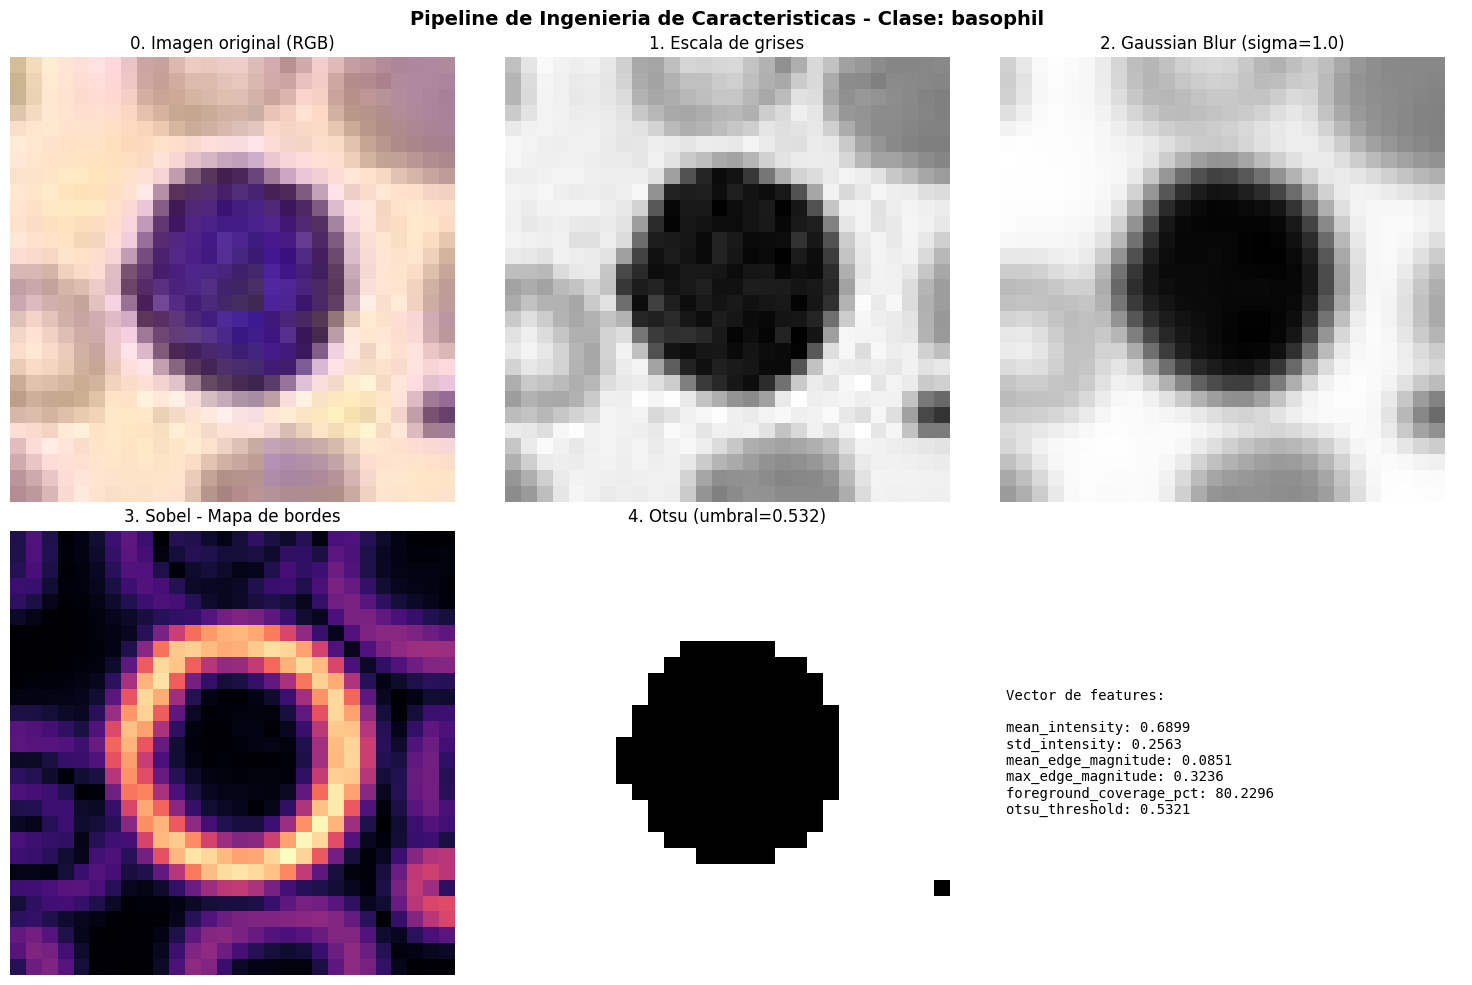

In [ ]:
example_class = 0
example_image = sample_images[example_class]
example_class_name = class_labels[str(example_class)]

result = extract_traditional_features(example_image, sigma=1.0)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Pipeline de Ingenieria de Caracteristicas - Clase: {example_class_name}", fontsize=14, fontweight="bold")

axes[0, 0].imshow(example_image)
axes[0, 0].set_title("0. Imagen original (RGB)")
axes[0, 0].axis("off")

axes[0, 1].imshow(result["gray"], cmap="gray")
axes[0, 1].set_title("1. Escala de grises")
axes[0, 1].axis("off")

axes[0, 2].imshow(result["blurred"], cmap="gray")
axes[0, 2].set_title("2. Gaussian Blur (sigma=1.0)")
axes[0, 2].axis("off")

axes[1, 0].imshow(result["edge_map"], cmap="magma")
axes[1, 0].set_title("3. Sobel - Mapa de bordes")
axes[1, 0].axis("off")

axes[1, 1].imshow(result["binary_mask"], cmap="gray")
axes[1, 1].set_title(f"4. Otsu (umbral={result['features']['otsu_threshold']:.3f})")
axes[1, 1].axis("off")

axes[1, 2].axis("off")
feature_text = "\n".join([f"{k}: {v:.4f}" for k, v in result["features"].items()])
axes[1, 2].text(0.05, 0.5, f"Vector de features:\n\n{feature_text}",
                 fontsize=10, family="monospace", verticalalignment="center")

plt.tight_layout()
plt.savefig("pipeline_ejemplo_unico.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Aplicando el pipeline a las 8 clases

Repetimos el proceso para una imagen representativa de cada clase, y comparamos visualmente los mapas de Sobel y Otsu, esto ayuda a inspeccionar si hay diferencias de textura/bordes/densidad visibles entre tipos de células.

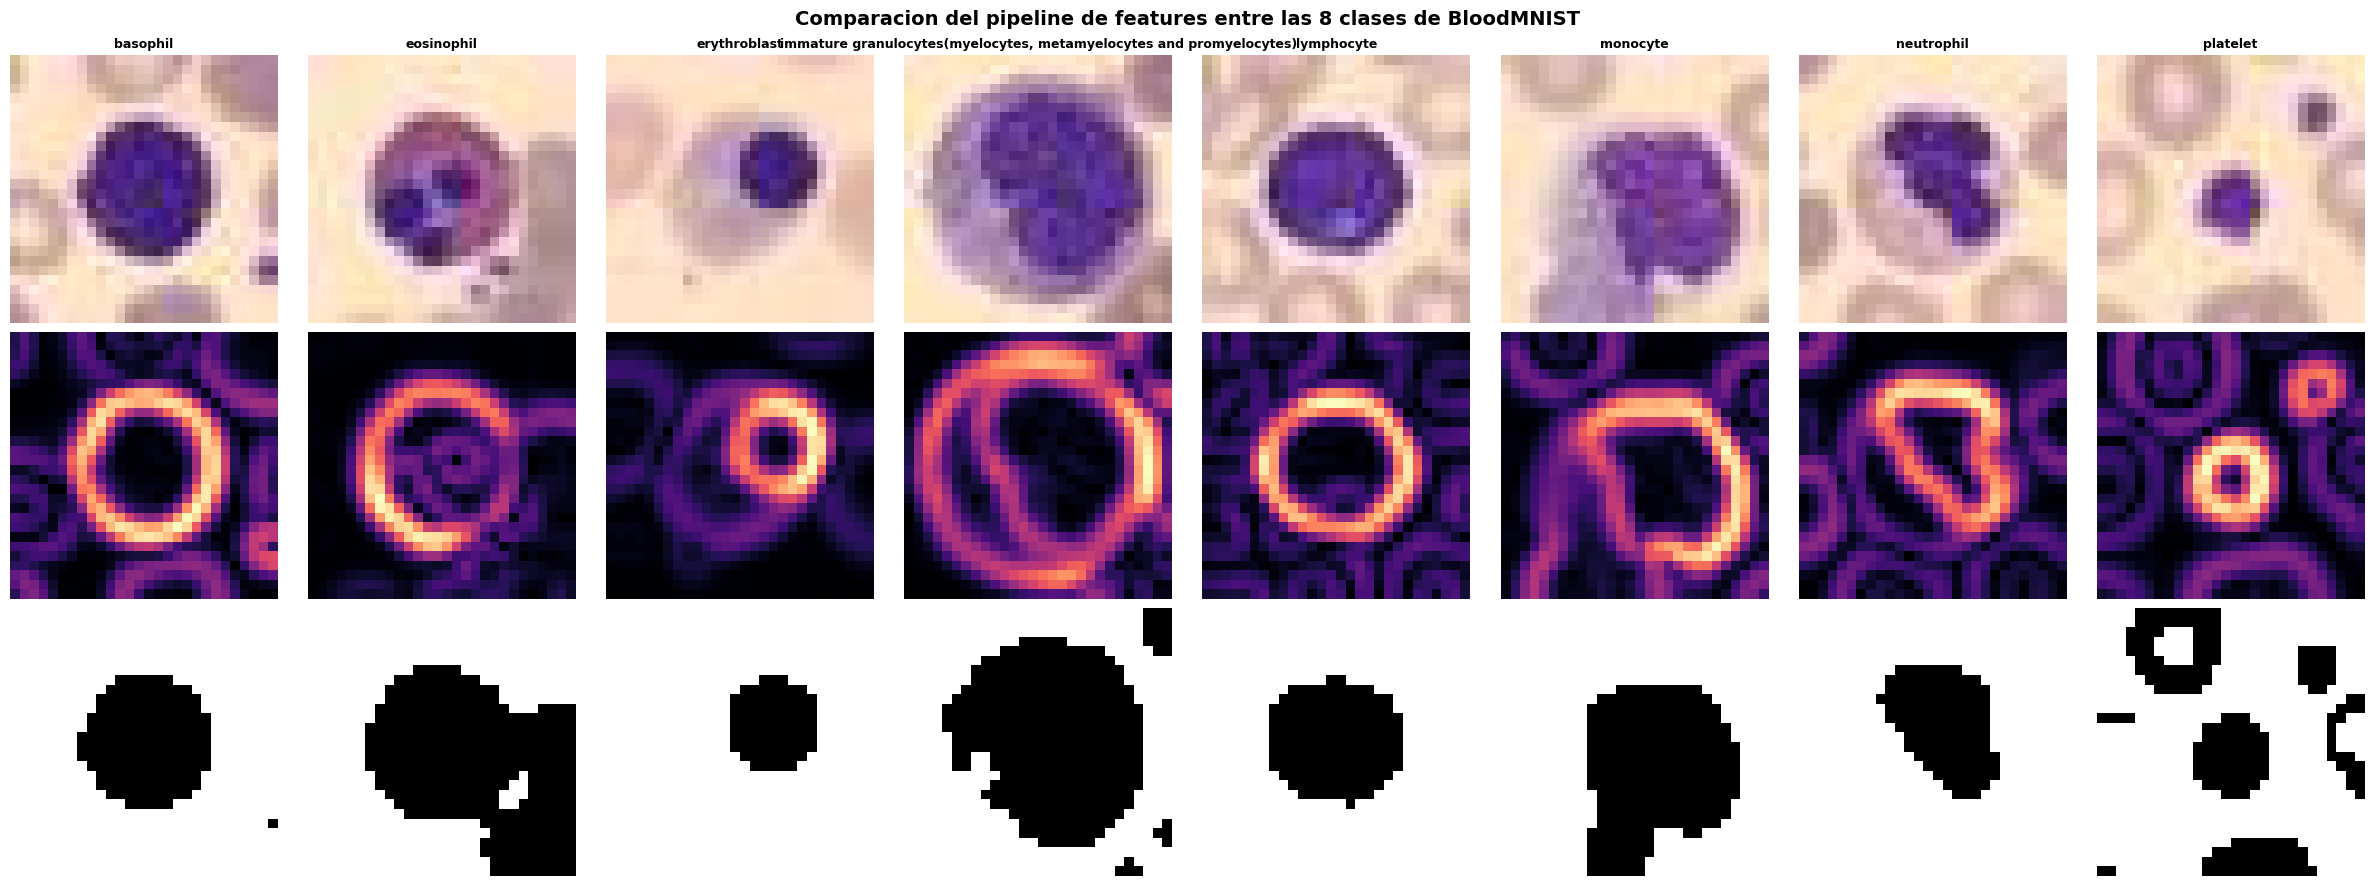

In [ ]:
all_results = {}
for class_idx, img in sample_images.items():
    all_results[class_idx] = extract_traditional_features(img, sigma=1.0)

n_classes = len(sample_images)
fig, axes = plt.subplots(3, n_classes, figsize=(3 * n_classes, 9))
fig.suptitle("Comparacion del pipeline de features entre las 8 clases de BloodMNIST", fontsize=14, fontweight="bold")

for col, class_idx in enumerate(sample_images.keys()):
    class_name = class_labels[str(class_idx)]
    r = all_results[class_idx]

    axes[0, col].imshow(sample_images[class_idx])
    axes[0, col].set_title(class_name, fontsize=9, fontweight="bold")
    axes[0, col].axis("off")

    axes[1, col].imshow(r["edge_map"], cmap="magma")
    axes[1, col].axis("off")
    if col == 0:
        axes[1, col].set_ylabel("Sobel", fontsize=10)

    axes[2, col].imshow(r["binary_mask"], cmap="gray")
    axes[2, col].axis("off")
    if col == 0:
        axes[2, col].set_ylabel("Otsu", fontsize=10)

plt.tight_layout()
plt.savefig("comparacion_8_clases.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Tabla comparativa de vectores de features por clase

In [ ]:
rows = []
for class_idx, r in all_results.items():
    row = {"clase": class_labels[str(class_idx)]}
    row.update(r["features"])
    rows.append(row)

features_df = pd.DataFrame(rows).set_index("clase")
features_df = features_df.round(4)
features_df


,mean_intensity,std_intensity,mean_edge_magnitude,max_edge_magnitude,foreground_coverage_pct,otsu_threshold
clase,,,,,,
basophil,0.6899,0.2563,0.0851,0.3236,80.2296,0.5321
eosinophil,0.7155,0.2307,0.0597,0.3094,57.2704,0.6879
erythroblast,0.7883,0.1792,0.0495,0.2899,90.3061,0.5947
"immature granulocytes(myelocytes, metamyelocytes and promyelocytes)",0.5845,0.2501,0.0771,0.2529,54.2092,0.5678
lymphocyte,0.6958,0.2199,0.0714,0.3045,80.7398,0.5555
monocyte,0.6847,0.2168,0.0643,0.2422,68.1122,0.6157
neutrophil,0.7350,0.2136,0.0721,0.3010,84.4388,0.5754
platelet,0.8019,0.1421,0.0618,0.2682,73.8520,0.7524


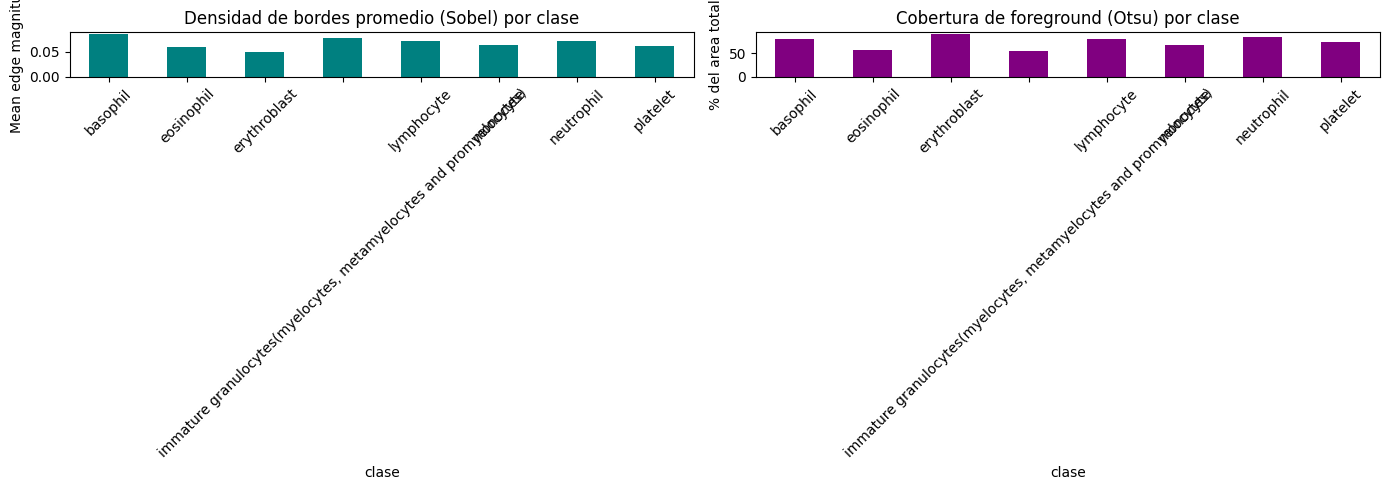

In [ ]:
# Visualizacion en barras de las features mas relevantes por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features_df["mean_edge_magnitude"].plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Densidad de bordes promedio (Sobel) por clase")
axes[0].set_ylabel("Mean edge magnitude")
axes[0].tick_params(axis="x", rotation=45)

features_df["foreground_coverage_pct"].plot(kind="bar", ax=axes[1], color="purple")
axes[1].set_title("Cobertura de foreground (Otsu) por clase")
axes[1].set_ylabel("% del area total")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("features_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Conclusión

- El **mapa de Sobel** aproxima manualmente lo que el Stem* (`Conv3x3 + BN + ReLU`) de la red aprende automáticamente en sus primeros filtros, detección de bordes y contornos celulares.
- La **binarización de Otsu** aproxima la separación célula/fondo que las capas más profundas de la red terminan codificando implícitamente en sus mapas de activación.
- Las diferencias visibles en densidad de bordes y cobertura de foreground entre clases (tabla de la sección 5) sugieren que **existe señal discriminativa** en textura y morfología,lo que justifica por qué un enfoque de Deep Learning basado en convoluciones es apropiado para este problema de clasificación.
- Cabe mencionar que la CNN aprende estos descriptores de forma end-to-end y jerárquica, ajustándolos directamente para maximizar precisión de clasificación en vez de depender de heurísticas fijas como sigma de Gaussian Blur o el umbral de Otsu.
